# Clustering and Segmentation

## Environmental Degradation and Well-being Analysis

### Objectives:
1. Identify distinct groups of countries/regions with similar environmental profiles
2. Apply clustering algorithms (K-Means, Hierarchical, DBSCAN)
3. Reduce dimensionality using PCA for visualization
4. Profile and characterize each cluster
5. Generate targeted recommendations for different segments

### Key Questions:
- Can we identify distinct patterns of environmental behavior?
- Which countries/regions share similar environmental characteristics?
- What factors distinguish high-performing from low-performing groups?
- How can we tailor recommendations to different segments?

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load and Prepare Data

In [3]:
# Load the processed dataset
df = pd.read_csv('../data/processed/master_dataset.csv')

print(f"Dataset loaded: {df.shape}")
print(f"Years available: {df['year'].min()} - {df['year'].max()}")

# Use most recent year with good data coverage (2020)
df_recent = df[df['year'] == 2020].copy()
print(f"\nData for 2020: {len(df_recent)} countries/regions")

# Select features for clustering based on available data
clustering_features = [
    'pm25_air_pollution',
    'energy_use_per_capita',
    'forest_area_percent',
    'gdp_per_capita',
    'population_total',
    'urban_population_percent',
    'life_expectancy',
    'agricultural_land_percent'
]

print(f"\nClustering features:")
for feature in clustering_features:
    count = df_recent[feature].notna().sum()
    print(f"  {feature}: {count} countries")

# Keep only rows with complete data for all clustering features
X = df_recent[clustering_features].dropna()
df_clean = df_recent.loc[X.index].copy()

print(f"\nCountries with complete data: {len(df_clean)}")
print(f"\nData prepared for clustering")


Dataset loaded: (17290, 20)
Years available: 1960 - 2024

Data for 2020: 266 countries/regions

Clustering features:
  pm25_air_pollution: 248 countries
  energy_use_per_capita: 193 countries
  forest_area_percent: 262 countries
  gdp_per_capita: 258 countries
  population_total: 265 countries
  urban_population_percent: 265 countries
  life_expectancy: 265 countries
  agricultural_land_percent: 258 countries

Countries with complete data: 186

Data prepared for clustering


## 2. Feature Scaling

In [4]:
# Scale features for clustering
# Essential because clustering algorithms are sensitive to scale

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create scaled dataframe for easier interpretation
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=X.index)

print("Features scaled successfully")
print(f"Scaled data shape: {X_scaled.shape}")
print(f"\nScaled data statistics:")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")


Features scaled successfully
Scaled data shape: (186, 8)

Scaled data statistics:
  Mean: 0.000000
  Std: 1.000000


## 3. Principal Component Analysis (PCA)

### 3.1 Perform PCA for Dimensionality Reduction

Number of components: 8

Variance explained by each component:
  PC1: 0.419 (41.9%)
  PC2: 0.165 (16.5%)
  PC3: 0.141 (14.1%)
  PC4: 0.116 (11.6%)
  PC5: 0.055 (5.5%)
  PC6: 0.043 (4.3%)
  PC7: 0.035 (3.5%)
  PC8: 0.027 (2.7%)

Cumulative variance:
  First 2 PCs: 0.583 (58.3%)
  First 3 PCs: 0.724 (72.4%)
  First 4 PCs: 0.840 (84.0%)

Saved: pca_variance.png


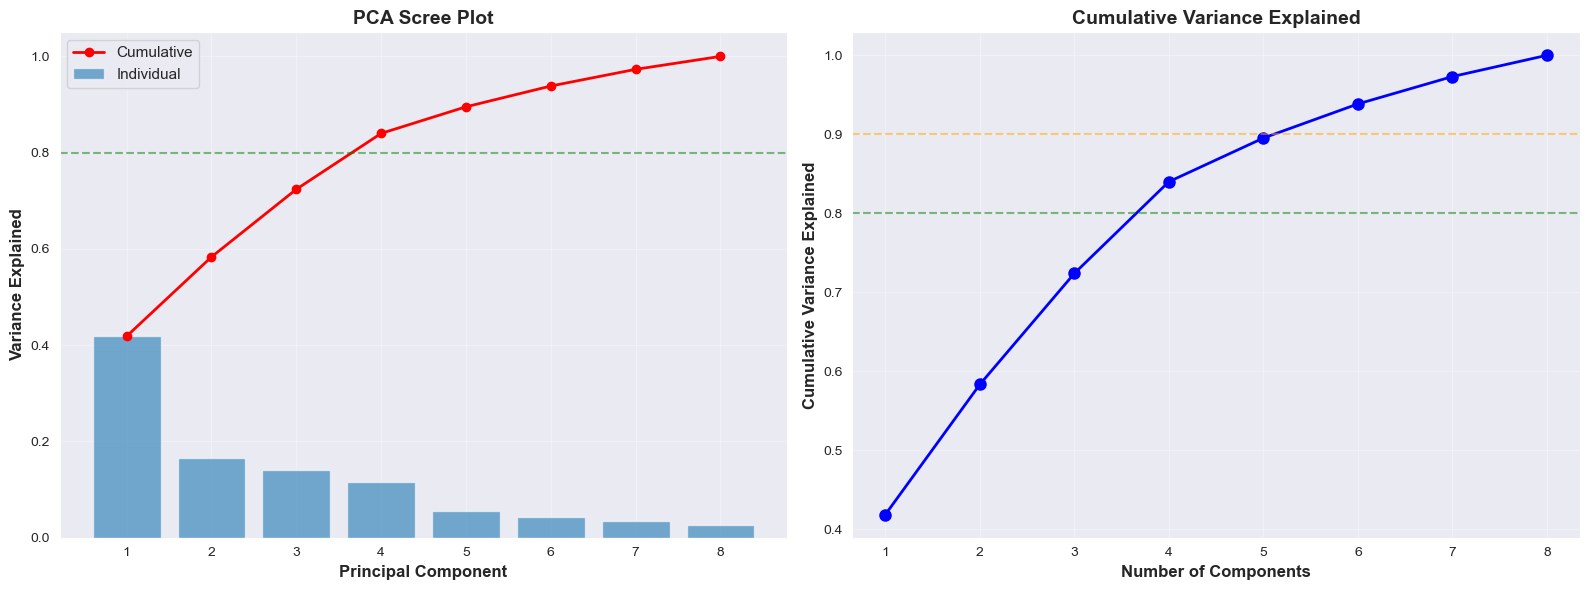


PCA performed successfully


In [5]:
# Apply PCA for dimensionality reduction
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Number of components: {len(explained_variance)}")
print(f"\nVariance explained by each component:")
for i, var in enumerate(explained_variance, 1):
    print(f"  PC{i}: {var:.3f} ({var*100:.1f}%)")

print(f"\nCumulative variance:")
print(f"  First 2 PCs: {cumulative_variance[1]:.3f} ({cumulative_variance[1]*100:.1f}%)")
print(f"  First 3 PCs: {cumulative_variance[2]:.3f} ({cumulative_variance[2]*100:.1f}%)")
print(f"  First 4 PCs: {cumulative_variance[3]:.3f} ({cumulative_variance[3]*100:.1f}%)")

# Visualize variance explained
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, label='Individual')
ax1.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, label='Cumulative')
ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Variance Explained', fontsize=12, fontweight='bold')
ax1.set_title('PCA Scree Plot', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='80% threshold')

# Cumulative variance only
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
ax2.axhline(y=0.9, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/processed/pca_variance.png', dpi=300, bbox_inches='tight')
print("\nSaved: pca_variance.png")
plt.show()

print("\nPCA performed successfully")


### 3.2 Interpret Principal Components

Component Loadings (First 4 components):
                             PC1    PC2    PC3    PC4
pm25_air_pollution        -0.342 -0.226 -0.545 -0.304
energy_use_per_capita      0.402 -0.238 -0.361 -0.206
forest_area_percent        0.116  0.791  0.062  0.080
gdp_per_capita             0.455 -0.197  0.010  0.088
population_total          -0.117  0.004 -0.514  0.839
urban_population_percent   0.453 -0.077 -0.031 -0.014
life_expectancy            0.478 -0.114  0.058  0.222
agricultural_land_percent -0.232 -0.456  0.548  0.313

COMPONENT INTERPRETATIONS:

PC1 (Development & Urbanization):
  life_expectancy: 0.478
  gdp_per_capita: 0.455
  urban_population_percent: 0.453

PC2 (Environmental Quality):
  forest_area_percent: 0.791
  agricultural_land_percent: -0.456
  energy_use_per_capita: -0.238

PC3 (Population & Density):
  agricultural_land_percent: 0.548
  pm25_air_pollution: -0.545
  population_total: -0.514

Saved: pca_loadings_heatmap.png


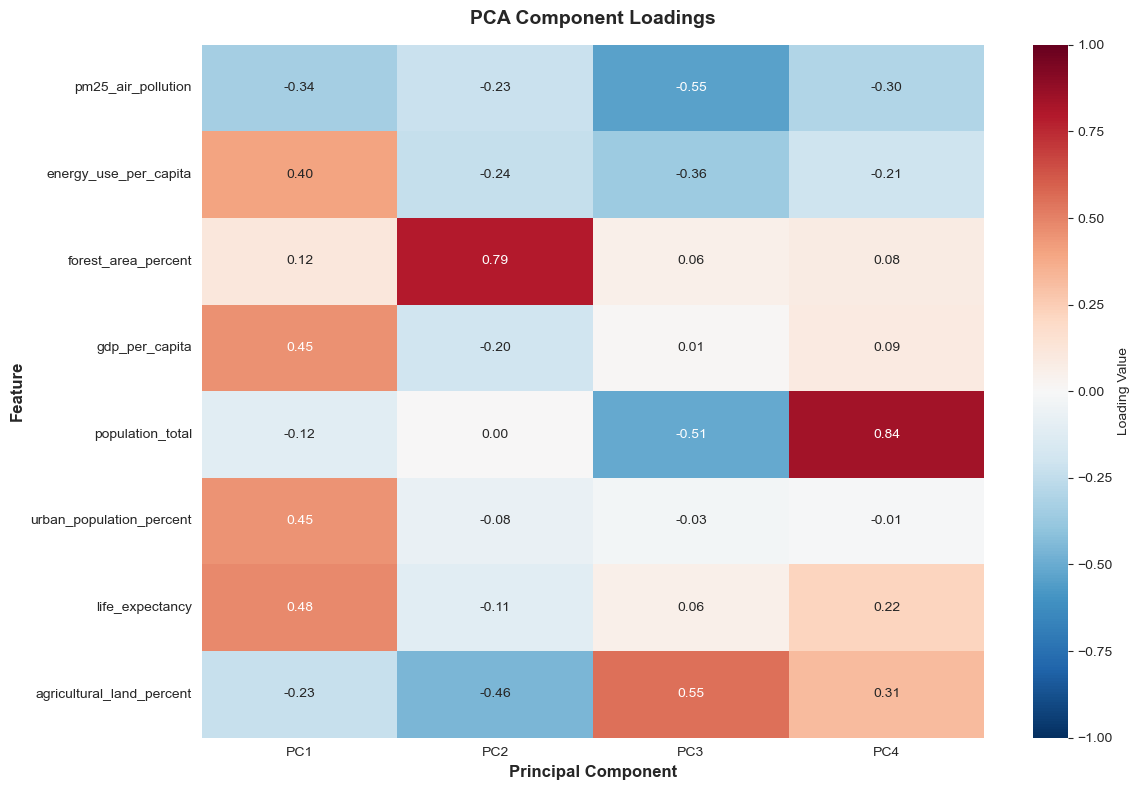


Component interpretation complete


In [6]:
# Examine component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=clustering_features
)

print("Component Loadings (First 4 components):")
print("=" * 80)
print(loadings[['PC1', 'PC2', 'PC3', 'PC4']].round(3))

# Interpret components
print("\n" + "=" * 80)
print("COMPONENT INTERPRETATIONS:")
print("=" * 80)

print("\nPC1 (Development & Urbanization):")
pc1_sorted = loadings['PC1'].abs().sort_values(ascending=False)
for feature in pc1_sorted.head(3).index:
    print(f"  {feature}: {loadings.loc[feature, 'PC1']:.3f}")

print("\nPC2 (Environmental Quality):")
pc2_sorted = loadings['PC2'].abs().sort_values(ascending=False)
for feature in pc2_sorted.head(3).index:
    print(f"  {feature}: {loadings.loc[feature, 'PC2']:.3f}")

print("\nPC3 (Population & Density):")
pc3_sorted = loadings['PC3'].abs().sort_values(ascending=False)
for feature in pc3_sorted.head(3).index:
    print(f"  {feature}: {loadings.loc[feature, 'PC3']:.3f}")

# Heatmap of loadings
plt.figure(figsize=(12, 8))
sns.heatmap(loadings[['PC1', 'PC2', 'PC3', 'PC4']], annot=True, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, fmt='.2f',
            cbar_kws={'label': 'Loading Value'})
plt.title('PCA Component Loadings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Principal Component', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
print("\nSaved: pca_loadings_heatmap.png")
plt.show()

print("\nComponent interpretation complete")


## 4. Determine Optimal Number of Clusters

### 4.1 Elbow Method

ELBOW METHOD FOR OPTIMAL K
k=2: Inertia = 1063.51
k=3: Inertia = 887.78
k=4: Inertia = 757.61
k=5: Inertia = 658.10
k=6: Inertia = 572.38
k=7: Inertia = 531.89
k=8: Inertia = 491.04
k=9: Inertia = 453.52
k=10: Inertia = 423.65

Saved: elbow_method.png


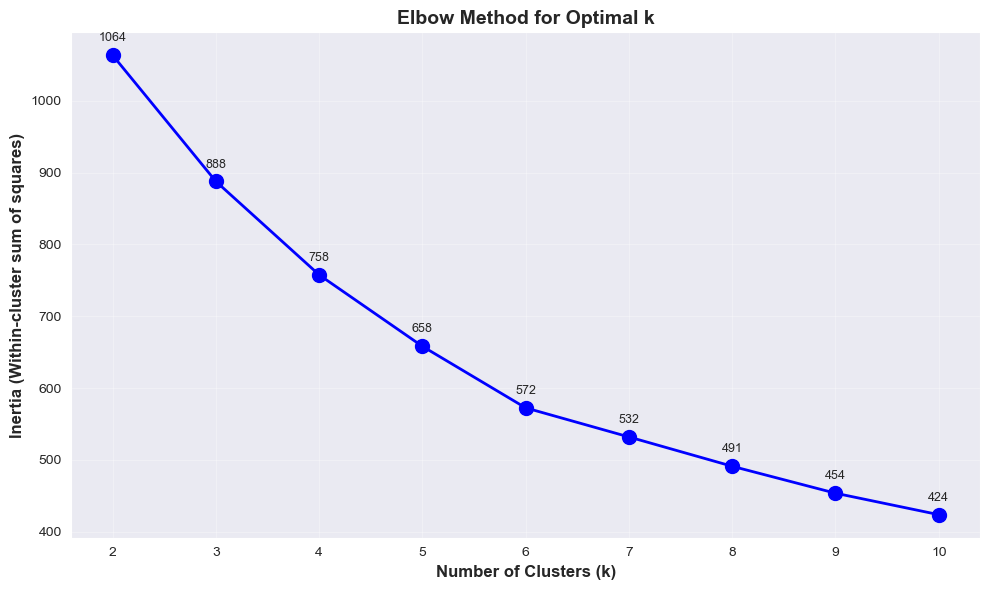


Elbow method complete
Look for the 'elbow' where the rate of decrease sharply changes


In [7]:
# Use elbow method to find optimal k
print("ELBOW METHOD FOR OPTIMAL K")
print("=" * 80)

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Annotate points
for k, inertia in zip(k_range, inertias):
    plt.annotate(f'{inertia:.0f}', (k, inertia), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/elbow_method.png', dpi=300, bbox_inches='tight')
print("\nSaved: elbow_method.png")
plt.show()

print("\nElbow method complete")
print("Look for the 'elbow' where the rate of decrease sharply changes")


### 4.2 Silhouette Analysis

SILHOUETTE ANALYSIS
k=2: Silhouette=0.262, Calinski-Harabasz=73.4, Davies-Bouldin=1.440
k=3: Silhouette=0.231, Calinski-Harabasz=61.9, Davies-Bouldin=1.474
k=4: Silhouette=0.248, Calinski-Harabasz=58.5, Davies-Bouldin=1.225
k=5: Silhouette=0.261, Calinski-Harabasz=57.1, Davies-Bouldin=1.145
k=6: Silhouette=0.245, Calinski-Harabasz=57.6, Davies-Bouldin=1.147
k=7: Silhouette=0.231, Calinski-Harabasz=53.6, Davies-Bouldin=1.216
k=8: Silhouette=0.240, Calinski-Harabasz=51.6, Davies-Bouldin=1.148
k=9: Silhouette=0.246, Calinski-Harabasz=50.5, Davies-Bouldin=1.112
k=10: Silhouette=0.263, Calinski-Harabasz=49.1, Davies-Bouldin=1.063

Saved: clustering_metrics.png


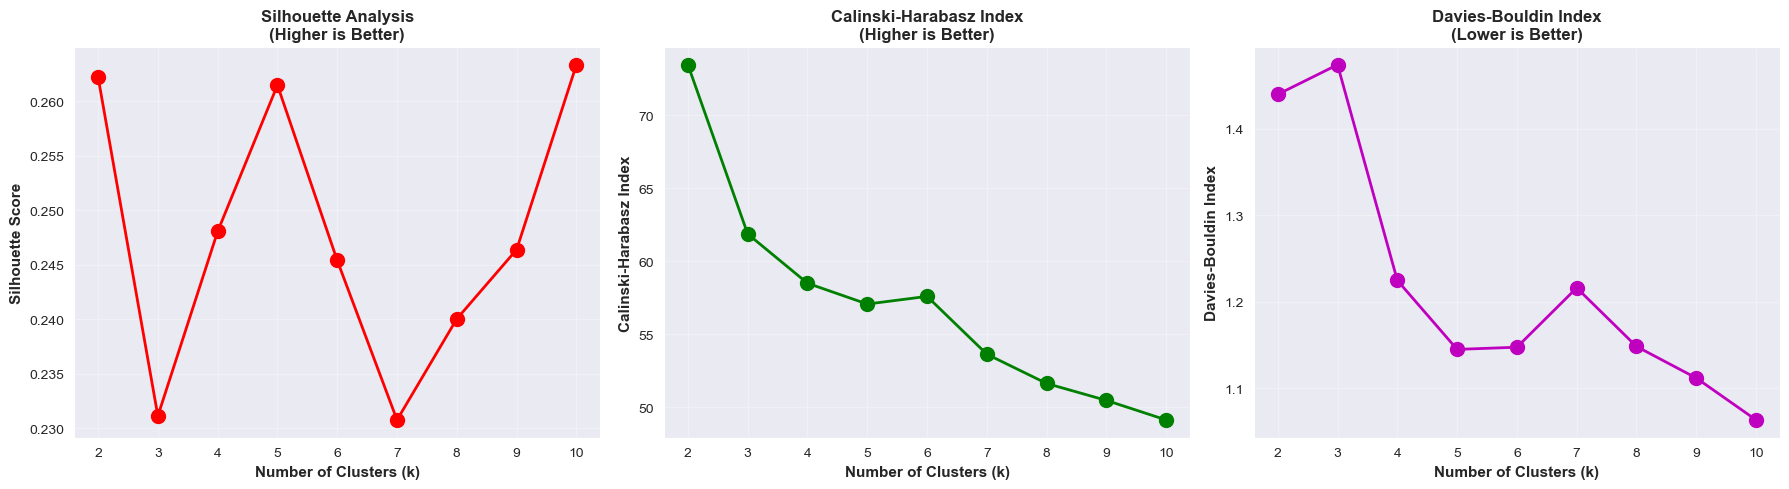


OPTIMAL NUMBER OF CLUSTERS: 10
  Silhouette Score: 0.263
  Calinski-Harabasz: 49.1
  Davies-Bouldin: 1.063

Silhouette analysis complete


In [8]:
# Calculate silhouette scores for different k values
print("SILHOUETTE ANALYSIS")
print("=" * 80)

silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(X_scaled, labels)
    calinski = calinski_harabasz_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)

    silhouette_scores.append(silhouette)
    calinski_scores.append(calinski)
    davies_bouldin_scores.append(davies_bouldin)

    print(f"k={k}: Silhouette={silhouette:.3f}, Calinski-Harabasz={calinski:.1f}, Davies-Bouldin={davies_bouldin:.3f}")

# Plot all metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette score (higher is better)
axes[0].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Silhouette Score', fontsize=11, fontweight='bold')
axes[0].set_title('Silhouette Analysis\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Calinski-Harabasz (higher is better)
axes[1].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Calinski-Harabasz Index', fontsize=11, fontweight='bold')
axes[1].set_title('Calinski-Harabasz Index\n(Higher is Better)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range)

# Davies-Bouldin (lower is better)
axes[2].plot(k_range, davies_bouldin_scores, 'mo-', linewidth=2, markersize=10)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11, fontweight='bold')
axes[2].set_title('Davies-Bouldin Index\n(Lower is Better)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_range)

plt.tight_layout()
plt.savefig('../data/processed/clustering_metrics.png', dpi=300, bbox_inches='tight')
print("\nSaved: clustering_metrics.png")
plt.show()

# Determine optimal k based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n{'='*80}")
print(f"OPTIMAL NUMBER OF CLUSTERS: {optimal_k}")
print(f"  Silhouette Score: {silhouette_scores[optimal_k-2]:.3f}")
print(f"  Calinski-Harabasz: {calinski_scores[optimal_k-2]:.1f}")
print(f"  Davies-Bouldin: {davies_bouldin_scores[optimal_k-2]:.3f}")
print(f"{'='*80}")

print("\nSilhouette analysis complete")


## 5. K-Means Clustering

### 5.1 Fit K-Means Model

In [9]:
# Fit K-Means with optimal k
print("K-MEANS CLUSTERING")
print("=" * 80)

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print(f"K-Means clustering complete with k={optimal_k}")
print(f"\nCluster sizes:")
cluster_counts = df_clean['cluster_kmeans'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} countries ({count/len(df_clean)*100:.1f}%)")

print(f"\nCluster centers (scaled space):")
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=clustering_features)
print(centers_df.round(2))

print("\nK-Means model fitted successfully")


K-MEANS CLUSTERING
K-Means clustering complete with k=10

Cluster sizes:
  Cluster 0: 22 countries (11.8%)
  Cluster 1: 23 countries (12.4%)
  Cluster 2: 21 countries (11.3%)
  Cluster 3: 5 countries (2.7%)
  Cluster 4: 34 countries (18.3%)
  Cluster 5: 9 countries (4.8%)
  Cluster 6: 6 countries (3.2%)
  Cluster 7: 47 countries (25.3%)
  Cluster 8: 11 countries (5.9%)
  Cluster 9: 8 countries (4.3%)

Cluster centers (scaled space):
   pm25_air_pollution  energy_use_per_capita  forest_area_percent  \
0                0.02                  -0.56                 1.41   
1               -1.04                   0.72                -0.16   
2               -0.17                  -0.19                -0.97   
3                0.59                  -0.29                 0.04   
4                1.23                  -0.70                -0.48   
5               -1.02                   1.27                 1.60   
6                1.17                   3.94                -1.10   
7          

### 5.2 Visualize Clusters in PCA Space

VISUALIZING CLUSTERS IN PCA SPACE
Saved: clusters_2d.png


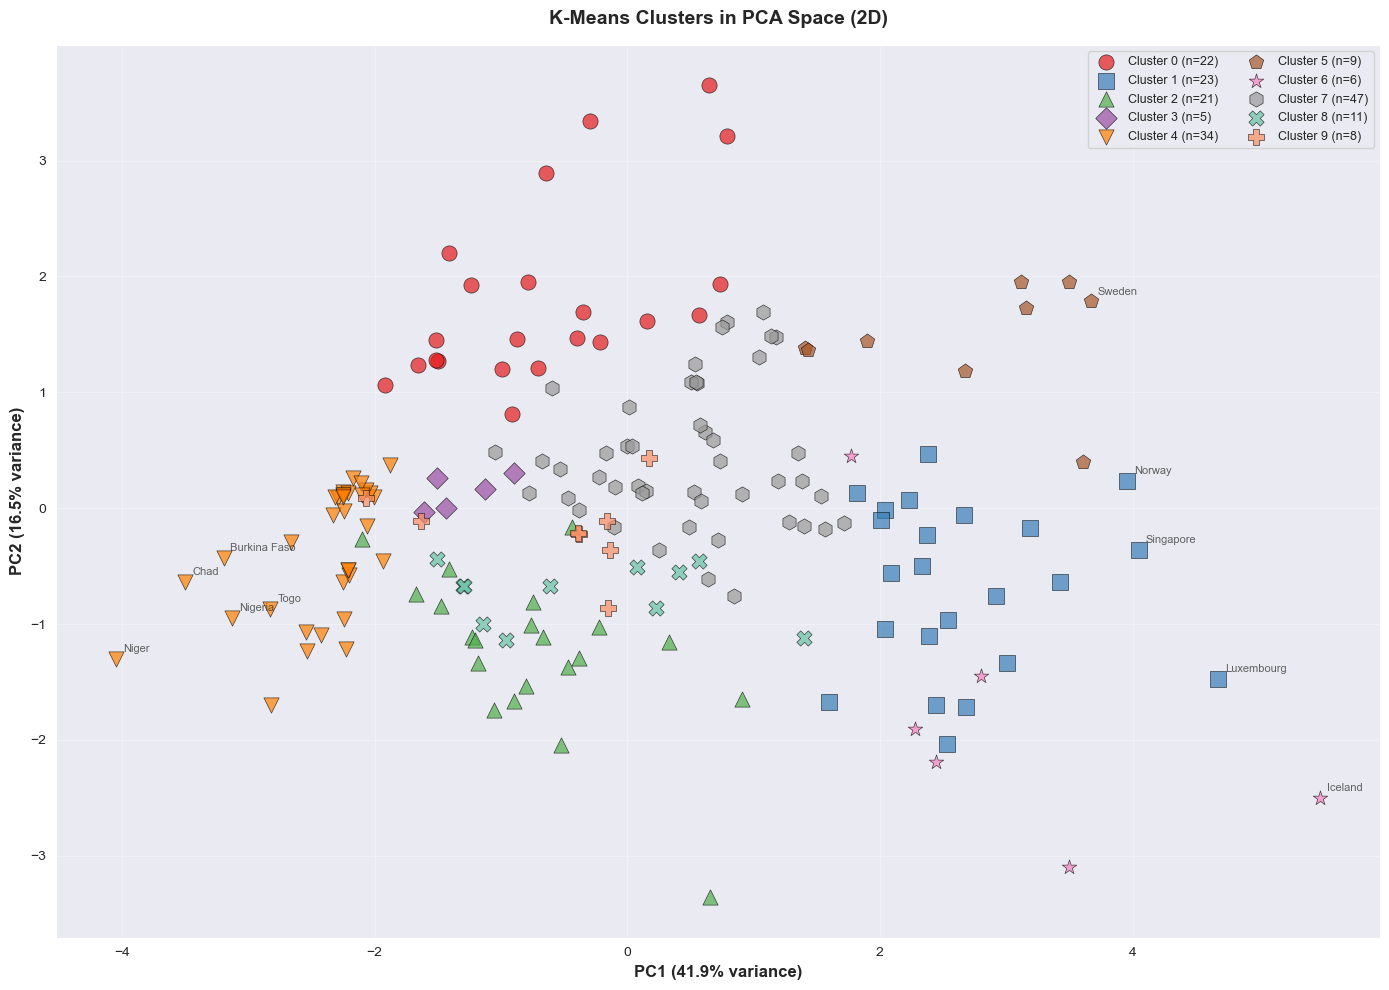


Total variance explained by 2 PCs: 58.3%
Cluster visualization created


In [11]:
# Visualize clusters using first 2 principal components
print("VISUALIZING CLUSTERS IN PCA SPACE")
print("=" * 80)

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_plot = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Cluster': df_clean['cluster_kmeans'].astype(str),
    'Country': df_clean['country_name'],
    'PM25': df_clean['pm25_air_pollution'],
    'GDP_per_capita': df_clean['gdp_per_capita']
})

# 2D scatter plot
plt.figure(figsize=(14, 10))

# Extended colors and markers for up to 10 clusters
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
          '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', 'P']

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    cluster_data = df_plot[df_plot['Cluster'] == str(cluster_id)]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'],
                c=colors[cluster_id % len(colors)],
                marker=markers[cluster_id % len(markers)],
                s=120, alpha=0.7, edgecolors='black', linewidth=0.5,
                label=f'Cluster {cluster_id} (n={len(cluster_data)})')

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)',
           fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)',
           fontsize=12, fontweight='bold')
plt.title('K-Means Clusters in PCA Space (2D)', fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=9, loc='best', ncol=2)
plt.grid(True, alpha=0.3)

# Add labels for extreme points
for _, row in df_plot.nlargest(5, 'PC1').iterrows():
    plt.annotate(row['Country'], (row['PC1'], row['PC2']),
                 fontsize=8, alpha=0.7, xytext=(5, 5),
                 textcoords='offset points')

for _, row in df_plot.nsmallest(5, 'PC1').iterrows():
    plt.annotate(row['Country'], (row['PC1'], row['PC2']),
                 fontsize=8, alpha=0.7, xytext=(5, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.savefig('../data/processed/clusters_2d.png', dpi=300, bbox_inches='tight')
print("Saved: clusters_2d.png")
plt.show()

print(f"\nTotal variance explained by 2 PCs: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print("Cluster visualization created")


### 5.3 Interactive 3D Visualization

In [12]:
# Create 3D interactive plot
print("CREATING 3D INTERACTIVE VISUALIZATION")
print("=" * 80)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

df_plot_3d = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Cluster': df_clean['cluster_kmeans'].astype(str),
    'Country': df_clean['country_name'],
    'PM25': df_clean['pm25_air_pollution'].round(2),
    'Energy': df_clean['energy_use_per_capita'].round(2),
    'GDP': df_clean['gdp_per_capita'].round(0),
    'Life_Expectancy': df_clean['life_expectancy'].round(1)
})

# Extended colors for up to 10 clusters
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
          '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62']

fig = px.scatter_3d(df_plot_3d, x='PC1', y='PC2', z='PC3',
                    color='Cluster', hover_name='Country',
                    hover_data={
                        'PC1': ':.2f',
                        'PC2': ':.2f',
                        'PC3': ':.2f',
                        'PM25': True,
                        'Energy': True,
                        'GDP': True,
                        'Life_Expectancy': True,
                        'Cluster': True
                    },
                    title=f'K-Means Clusters in 3D PCA Space ({pca_3d.explained_variance_ratio_.sum()*100:.1f}% variance)',
                    labels={'Cluster': 'Cluster ID'},
                    color_discrete_sequence=colors)

fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(
    font=dict(size=12),
    height=700,
    legend=dict(title=dict(text='Cluster'))
)

fig.write_html('../data/processed/clusters_3d.html')
print("Saved: clusters_3d.html")
fig.show()

print(f"\nVariance explained by 3 PCs:")
print(f"  PC1: {pca_3d.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca_3d.explained_variance_ratio_[1]*100:.1f}%")
print(f"  PC3: {pca_3d.explained_variance_ratio_[2]*100:.1f}%")
print(f"  Total: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%")
print("\n3D visualization created")


CREATING 3D INTERACTIVE VISUALIZATION
Saved: clusters_3d.html



Variance explained by 3 PCs:
  PC1: 41.9%
  PC2: 16.5%
  PC3: 14.1%
  Total: 72.4%

3D visualization created


## 6. Hierarchical Clustering

### 6.1 Create Dendrogram

HIERARCHICAL CLUSTERING
Sampling 50 countries for dendrogram visualization (out of 186)
Saved: dendrogram.png


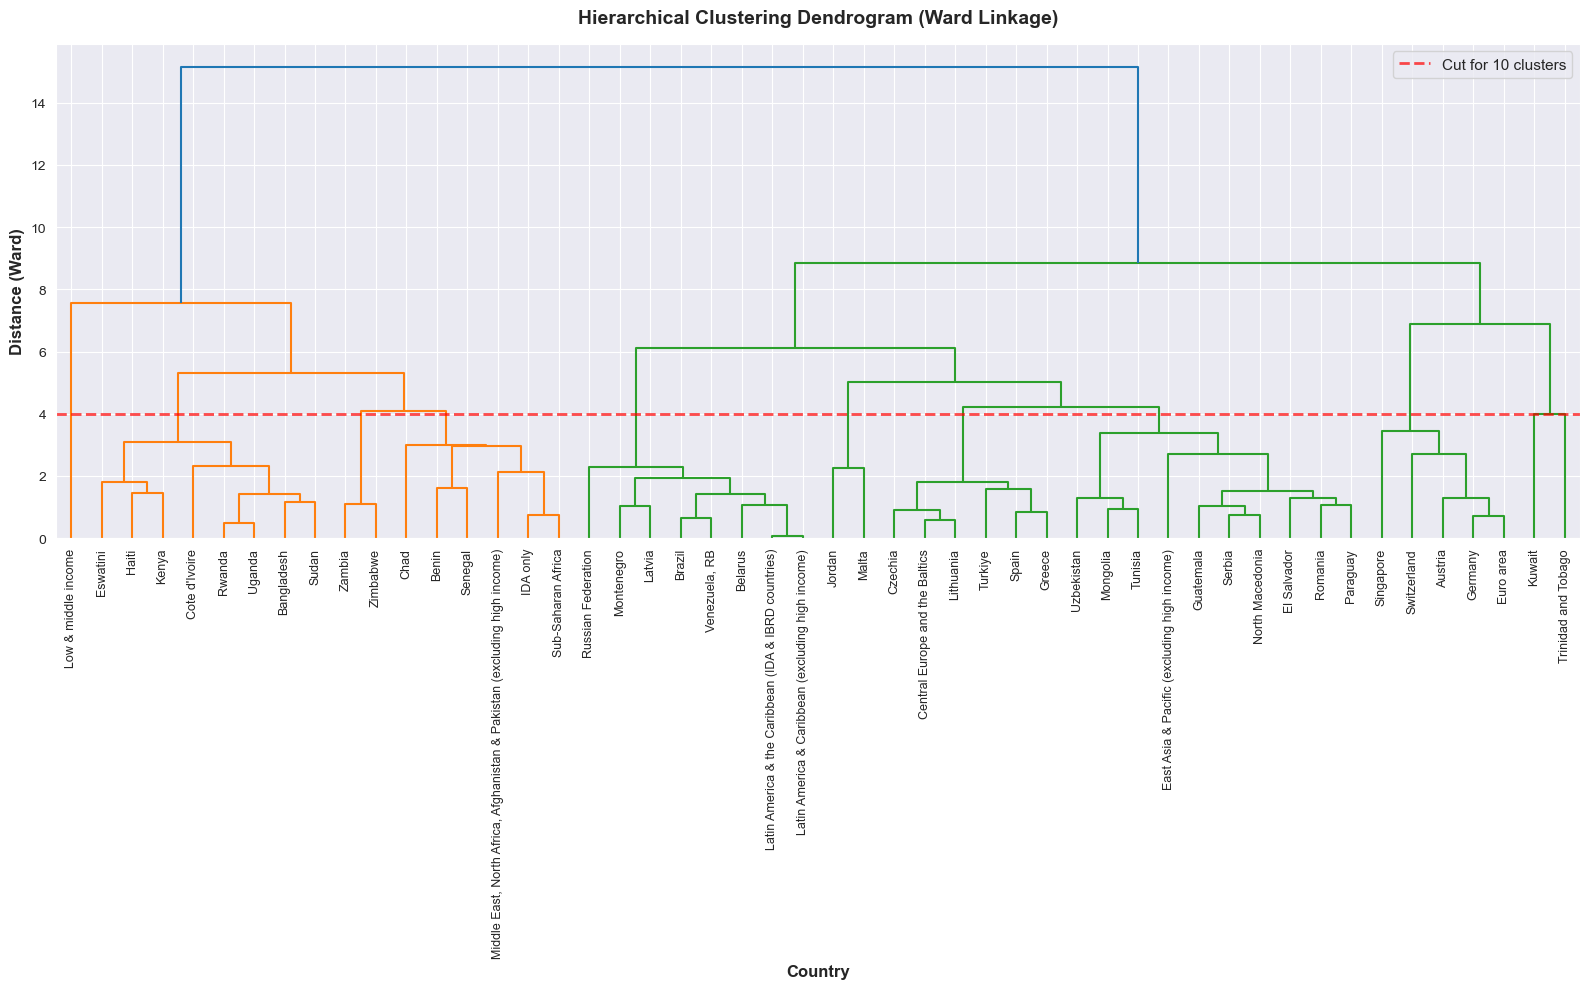


Dendrogram created


In [13]:
# Perform hierarchical clustering
print("HIERARCHICAL CLUSTERING")
print("=" * 80)

# Sample data for dendrogram if too many countries
if len(X_scaled) > 50:
    print(f"Sampling 50 countries for dendrogram visualization (out of {len(X_scaled)})")
    sample_idx = np.random.choice(len(X_scaled), 50, replace=False)
    X_sample = X_scaled[sample_idx]
    labels_sample = df_clean.iloc[sample_idx]['country_name'].values
else:
    X_sample = X_scaled
    labels_sample = df_clean['country_name'].values

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 10))
dendrogram(linkage_matrix, labels=labels_sample, leaf_font_size=9)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Distance (Ward)', fontsize=12, fontweight='bold')
plt.xticks(rotation=90)

# Add horizontal line at optimal cut
from scipy.cluster.hierarchy import fcluster
max_d = linkage_matrix[-optimal_k, 2]
plt.axhline(y=max_d, color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Cut for {optimal_k} clusters')
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/dendrogram.png', dpi=300, bbox_inches='tight')
print("Saved: dendrogram.png")
plt.show()

print("\nDendrogram created")


### 6.2 Fit Hierarchical Clustering Model

In [14]:
# Fit hierarchical clustering to all data
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df_clean['cluster_hierarchical'] = hierarchical.fit_predict(X_scaled)

print("Hierarchical clustering complete")
print(f"\nCluster sizes (Hierarchical):")
hier_counts = df_clean['cluster_hierarchical'].value_counts().sort_index()
for cluster_id, count in hier_counts.items():
    print(f"  Cluster {cluster_id}: {count} countries ({count/len(df_clean)*100:.1f}%)")

# Compare K-Means and Hierarchical clustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df_clean['cluster_kmeans'], df_clean['cluster_hierarchical'])
nmi = normalized_mutual_info_score(df_clean['cluster_kmeans'], df_clean['cluster_hierarchical'])

print(f"\nComparison between K-Means and Hierarchical:")
print(f"  Adjusted Rand Index: {ari:.3f} (1.0 = perfect agreement)")
print(f"  Normalized Mutual Information: {nmi:.3f} (1.0 = perfect agreement)")

if ari > 0.7:
    print("  → High agreement between methods")
elif ari > 0.4:
    print("  → Moderate agreement between methods")
else:
    print("  → Low agreement between methods")

print("\nHierarchical clustering fitted")


Hierarchical clustering complete

Cluster sizes (Hierarchical):
  Cluster 0: 41 countries (22.0%)
  Cluster 1: 23 countries (12.4%)
  Cluster 2: 17 countries (9.1%)
  Cluster 3: 12 countries (6.5%)
  Cluster 4: 42 countries (22.6%)
  Cluster 5: 6 countries (3.2%)
  Cluster 6: 10 countries (5.4%)
  Cluster 7: 5 countries (2.7%)
  Cluster 8: 13 countries (7.0%)
  Cluster 9: 17 countries (9.1%)

Comparison between K-Means and Hierarchical:
  Adjusted Rand Index: 0.623 (1.0 = perfect agreement)
  Normalized Mutual Information: 0.762 (1.0 = perfect agreement)
  → Moderate agreement between methods

Hierarchical clustering fitted


## 7. Cluster Profiling

### 7.1 Calculate Cluster Statistics

CLUSTER PROFILING

Cluster Profiles (Mean Values):
                pm25_air_pollution  energy_use_per_capita  \
cluster_kmeans                                              
0                            25.75                 757.34   
1                            10.32                3835.98   
2                            22.89                1642.56   
3                            33.95                1420.54   
4                            43.24                 425.41   
5                            10.58                5157.77   
6                            42.48               11591.70   
7                            16.52                1728.79   
8                            37.28                1817.52   
9                            32.56                1801.30   

                forest_area_percent  gdp_per_capita  population_total  \
cluster_kmeans                                                          
0                             57.85         3136.28      3.404757e+07 

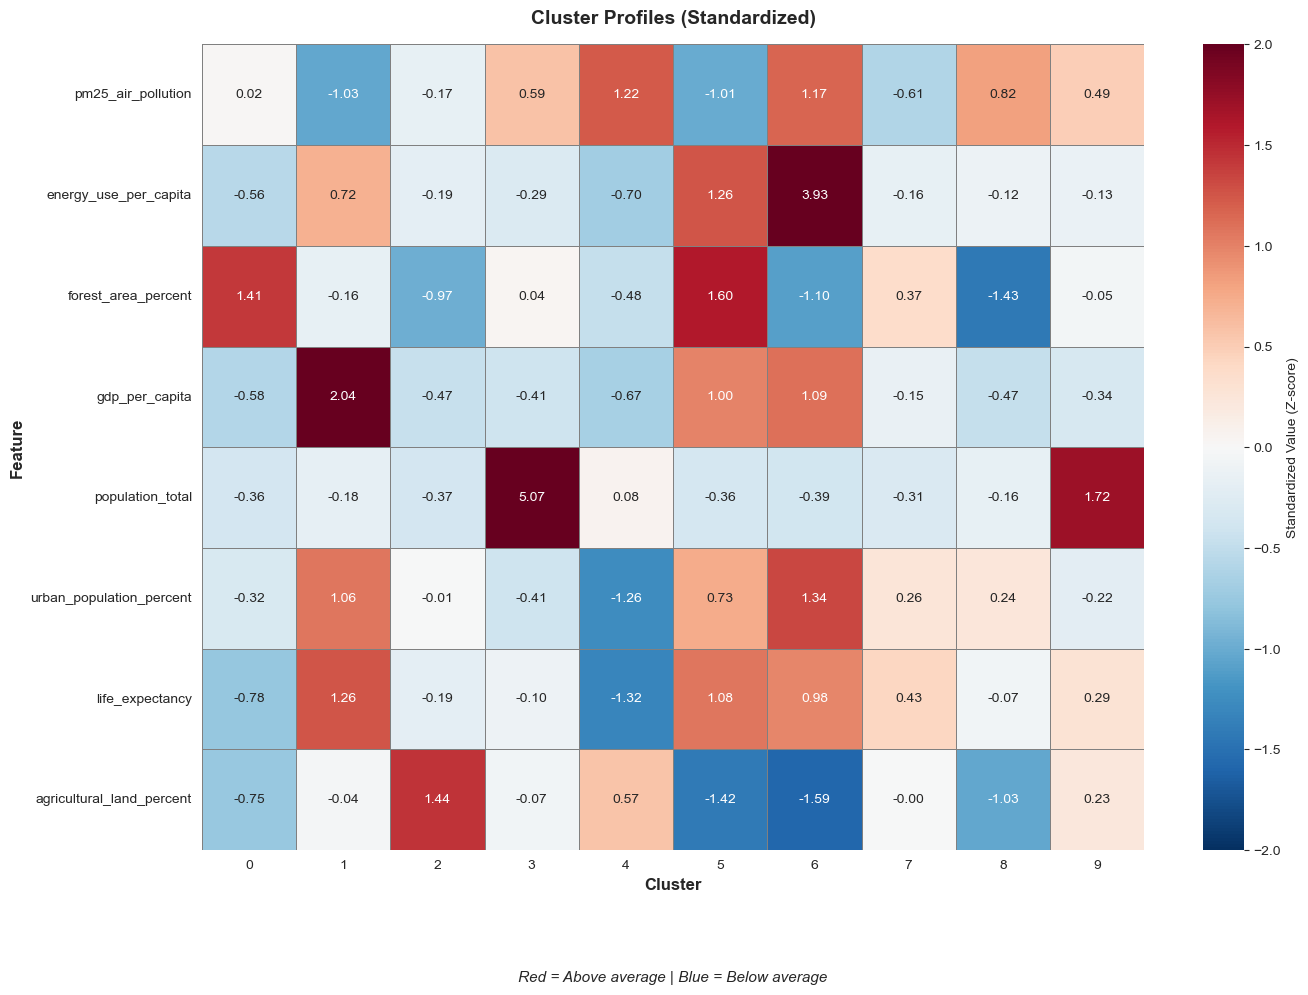


CLUSTER STATISTICS SUMMARY

Cluster 0:
  Size: 22 countries
  Key characteristics (vs global average):
    ↓ energy_use_per_capita: 757.34 (-64.1%)
    ↑ forest_area_percent: 57.85 (+92.3%)
    ↓ gdp_per_capita: 3136.28 (-78.3%)
    ↓ population_total: 34047566.05 (-92.5%)
    ↓ agricultural_land_percent: 26.03 (-35.7%)

Cluster 1:
  Size: 23 countries
  Key characteristics (vs global average):
    ↓ pm25_air_pollution: 10.32 (-59.4%)
    ↑ energy_use_per_capita: 3835.98 (+81.7%)
    ↑ gdp_per_capita: 54226.98 (+275.1%)
    ↓ population_total: 247911144.04 (-45.2%)
    ↑ urban_population_percent: 83.24 (+33.7%)

Cluster 2:
  Size: 21 countries
  Key characteristics (vs global average):
    ↓ energy_use_per_capita: 1642.56 (-22.2%)
    ↓ forest_area_percent: 10.95 (-63.6%)
    ↓ gdp_per_capita: 5360.37 (-62.9%)
    ↓ population_total: 28608476.00 (-93.7%)
    ↑ agricultural_land_percent: 68.18 (+68.5%)

Cluster 3:
  Size: 5 countries
  Key characteristics (vs global average):
    ↑ pm2

In [15]:
# Profile each cluster
print("CLUSTER PROFILING")
print("=" * 80)

cluster_profiles = df_clean.groupby('cluster_kmeans')[clustering_features].mean()
print("\nCluster Profiles (Mean Values):")
print("=" * 80)
print(cluster_profiles.round(2))

# Calculate global means for comparison
global_means = df_clean[clustering_features].mean()

# Standardize cluster profiles for visualization
cluster_profiles_normalized = (cluster_profiles - global_means) / df_clean[clustering_features].std()

# Visualize cluster profiles with heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cluster_profiles_normalized.T, annot=True, cmap='RdBu_r',
            center=0, vmin=-2, vmax=2, fmt='.2f',
            cbar_kws={'label': 'Standardized Value (Z-score)'},
            linewidths=0.5, linecolor='gray')
plt.title('Cluster Profiles (Standardized)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)

# Annotate interpretation
plt.text(0.5, -0.15, 'Red = Above average | Blue = Below average',
         ha='center', va='top', fontsize=11, style='italic',
         transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('../data/processed/cluster_profiles_heatmap.png', dpi=300, bbox_inches='tight')
print("\nSaved: cluster_profiles_heatmap.png")
plt.show()

# Statistical summary by cluster
print("\n" + "=" * 80)
print("CLUSTER STATISTICS SUMMARY")
print("=" * 80)

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    print(f"\nCluster {cluster_id}:")
    cluster_data = df_clean[df_clean['cluster_kmeans'] == cluster_id]
    print(f"  Size: {len(cluster_data)} countries")
    print(f"  Key characteristics (vs global average):")

    for feature in clustering_features:
        cluster_mean = cluster_data[feature].mean()
        global_mean = df_clean[feature].mean()
        diff_pct = ((cluster_mean - global_mean) / global_mean) * 100

        if abs(diff_pct) > 20:  # Only show significant differences
            direction = "↑" if diff_pct > 0 else "↓"
            print(f"    {direction} {feature}: {cluster_mean:.2f} ({diff_pct:+.1f}%)")

print("\nCluster profiling complete")


### 7.2 Name and Characterize Clusters

In [16]:
# Assign meaningful names to clusters based on characteristics
print("CLUSTER NAMING AND CHARACTERIZATION")
print("=" * 80)

# Analyze each cluster to determine appropriate names
cluster_characteristics = {}

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    cluster_data = df_clean[df_clean['cluster_kmeans'] == cluster_id]
    profile = cluster_profiles.loc[cluster_id]

    # Determine cluster name based on profile
    characteristics = []

    if profile['pm25_air_pollution'] > df_clean['pm25_air_pollution'].quantile(0.75):
        characteristics.append('High Pollution')
    elif profile['pm25_air_pollution'] < df_clean['pm25_air_pollution'].quantile(0.25):
        characteristics.append('Low Pollution')

    if profile['gdp_per_capita'] > df_clean['gdp_per_capita'].quantile(0.75):
        characteristics.append('High Income')
    elif profile['gdp_per_capita'] < df_clean['gdp_per_capita'].quantile(0.25):
        characteristics.append('Low Income')

    if profile['energy_use_per_capita'] > df_clean['energy_use_per_capita'].quantile(0.75):
        characteristics.append('High Energy')

    if profile['life_expectancy'] > df_clean['life_expectancy'].quantile(0.75):
        characteristics.append('High Well-being')

    cluster_characteristics[cluster_id] = characteristics

# Generate cluster names
cluster_names = {}
for cluster_id, chars in cluster_characteristics.items():
    if 'Low Pollution' in chars and 'High Income' in chars:
        cluster_names[cluster_id] = 'Green Leaders'
    elif 'High Pollution' in chars and 'High Energy' in chars:
        cluster_names[cluster_id] = 'Industrial Emitters'
    elif 'Low Income' in chars:
        cluster_names[cluster_id] = 'Developing Nations'
    elif 'High Income' in chars:
        cluster_names[cluster_id] = 'Advanced Economies'
    else:
        cluster_names[cluster_id] = f'Moderate Performers {cluster_id}'

df_clean['cluster_name'] = df_clean['cluster_kmeans'].map(cluster_names)

# Print countries in each cluster
print("\nClusters and Member Countries:")
print("=" * 80)

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    cluster_name = cluster_names[cluster_id]
    countries = df_clean[df_clean['cluster_kmeans'] == cluster_id]['country_name'].tolist()

    print(f"\nCluster {cluster_id}: {cluster_name}")
    print(f"  Size: {len(countries)} countries")
    print(f"  Characteristics: {', '.join(cluster_characteristics[cluster_id])}")
    print(f"  Countries: {', '.join(sorted(countries)[:15])}")
    if len(countries) > 15:
        print(f"    ... and {len(countries) - 15} more")

print("\nClusters named and characterized")


CLUSTER NAMING AND CHARACTERIZATION

Clusters and Member Countries:

Cluster 0: Moderate Performers 0
  Size: 22 countries
  Characteristics: 
  Countries: Angola, Bolivia, Cambodia, Cameroon, Congo, Dem. Rep., Congo, Rep., Ecuador, Equatorial Guinea, Gabon, Honduras, Indonesia, Jamaica, Lao PDR, Montenegro, Mozambique
    ... and 7 more

Cluster 1: Green Leaders
  Size: 23 countries
  Characteristics: Low Pollution, High Income, High Energy, High Well-being
  Countries: Australia, Austria, Belgium, Denmark, Euro area, European Union, France, Germany, High income, Ireland, Israel, Luxembourg, Malta, Netherlands, New Zealand
    ... and 8 more

Cluster 2: Moderate Performers 2
  Size: 21 countries
  Characteristics: 
  Countries: Armenia, Azerbaijan, El Salvador, Europe & Central Asia (excluding high income), Haiti, Kazakhstan, Kyrgyz Republic, Lebanon, Madagascar, Moldova, Mongolia, Morocco, Namibia, Saudi Arabia, South Africa
    ... and 6 more

Cluster 3: Moderate Performers 3
  Size

### 7.3 Detailed Cluster Descriptions

In [17]:
# Generate detailed descriptions for each cluster
print("DETAILED CLUSTER DESCRIPTIONS")
print("=" * 80)

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    print(f"\n{'=' * 80}")
    print(f"CLUSTER {cluster_id}: {cluster_names[cluster_id]}")
    print(f"{'=' * 80}")

    cluster_data = df_clean[df_clean['cluster_kmeans'] == cluster_id]

    print(f"\nSize: {len(cluster_data)} countries ({len(cluster_data)/len(df_clean)*100:.1f}% of total)")

    print(f"\nKey Characteristics:")
    for feature in clustering_features:
        cluster_mean = cluster_data[feature].mean()
        cluster_median = cluster_data[feature].median()
        cluster_std = cluster_data[feature].std()
        global_mean = df_clean[feature].mean()
        diff_pct = ((cluster_mean - global_mean) / global_mean) * 100

        print(f"\n  {feature}:")
        print(f"    Mean: {cluster_mean:.2f} (Global: {global_mean:.2f}, {diff_pct:+.1f}%)")
        print(f"    Median: {cluster_median:.2f}")
        print(f"    Std Dev: {cluster_std:.2f}")

    # Sample countries
    sample_countries = cluster_data['country_name'].sample(min(8, len(cluster_data))).tolist()
    print(f"\nRepresentative Countries:")
    print(f"  {', '.join(sorted(sample_countries))}")

    # Extreme values in cluster
    if len(cluster_data) > 3:
        print(f"\nNotable Members:")
        highest_pm25 = cluster_data.nlargest(2, 'pm25_air_pollution')['country_name'].tolist()
        lowest_pm25 = cluster_data.nsmallest(2, 'pm25_air_pollution')['country_name'].tolist()
        print(f"  Highest PM2.5: {', '.join(highest_pm25)}")
        print(f"  Lowest PM2.5: {', '.join(lowest_pm25)}")

print("\n" + "=" * 80)
print("Detailed cluster descriptions generated")


DETAILED CLUSTER DESCRIPTIONS

CLUSTER 0: Moderate Performers 0

Size: 22 countries (11.8% of total)

Key Characteristics:

  pm25_air_pollution:
    Mean: 25.75 (Global: 25.38, +1.4%)
    Median: 24.70
    Std Dev: 7.44

  energy_use_per_capita:
    Mean: 757.34 (Global: 2110.62, -64.1%)
    Median: 622.24
    Std Dev: 480.85

  forest_area_percent:
    Mean: 57.85 (Global: 30.07, +92.3%)
    Median: 54.27
    Std Dev: 15.50

  gdp_per_capita:
    Mean: 3136.28 (Global: 14457.98, -78.3%)
    Median: 2194.68
    Std Dev: 2175.12

  population_total:
    Mean: 34047566.05 (Global: 452515541.58, -92.5%)
    Median: 17135769.50
    Std Dev: 58542506.76

  urban_population_percent:
    Mean: 55.85 (Global: 62.24, -10.3%)
    Median: 56.99
    Std Dev: 16.66

  life_expectancy:
    Mean: 67.01 (Global: 72.42, -7.5%)
    Median: 66.92
    Std Dev: 4.59

  agricultural_land_percent:
    Mean: 26.03 (Global: 40.45, -35.7%)
    Median: 27.73
    Std Dev: 13.59

Representative Countries:
  Cambo

## 8. Cluster Comparison Visualizations

### 8.1 Radar Charts for Cluster Comparison

CREATING RADAR CHARTS FOR CLUSTER COMPARISON
Saved: cluster_radar.png


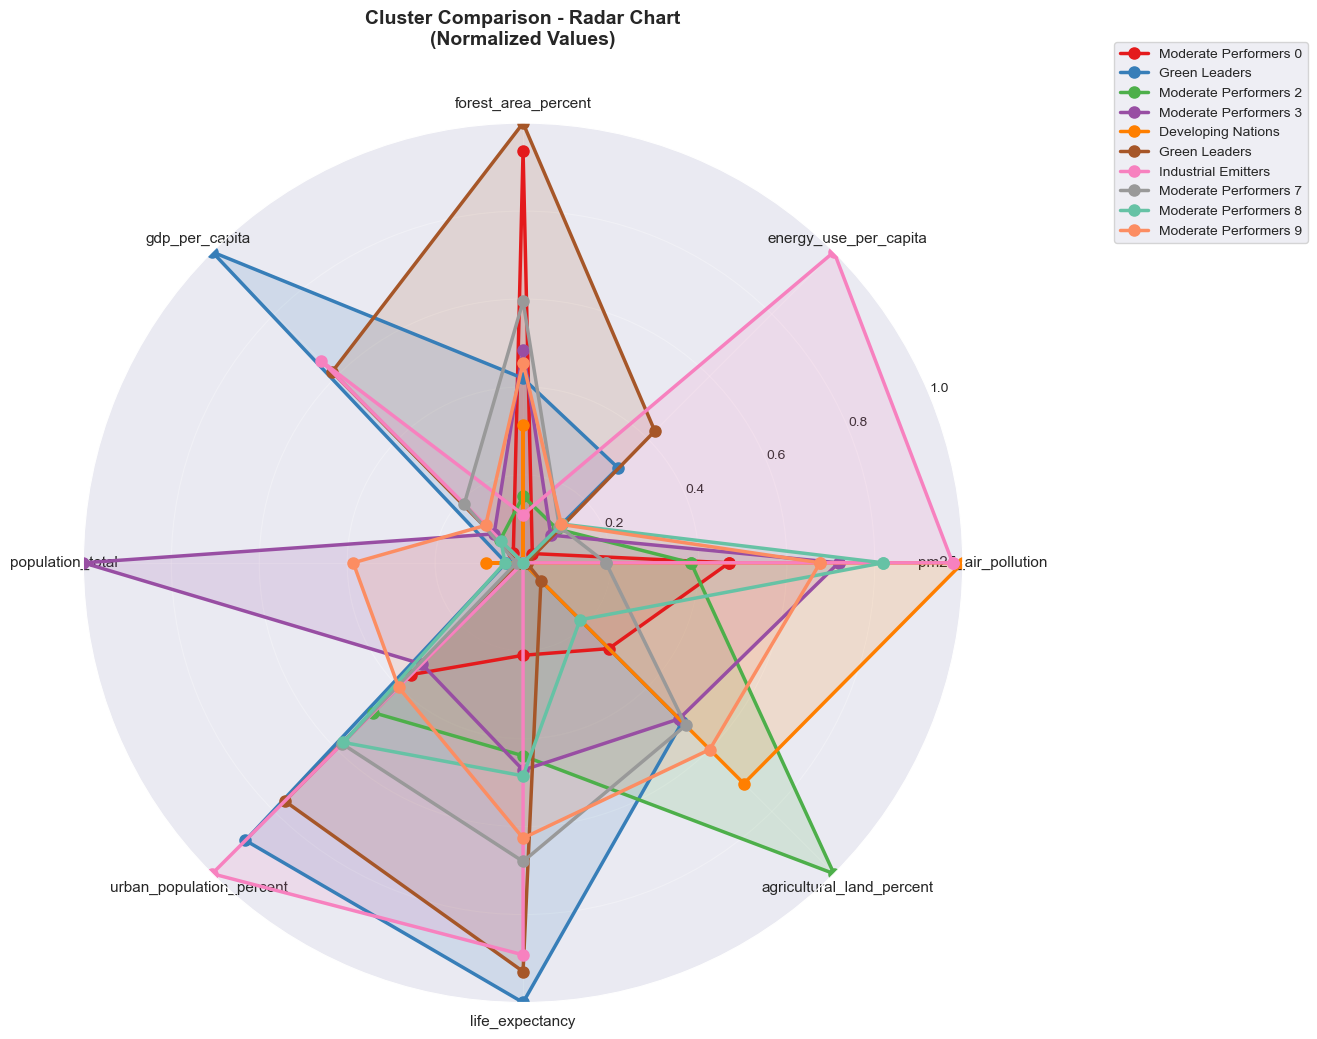

Radar charts created


In [18]:
# Create radar charts comparing clusters
print("CREATING RADAR CHARTS FOR CLUSTER COMPARISON")
print("=" * 80)

from math import pi

categories = clustering_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))

# Use normalized profiles for better visualization
cluster_profiles_norm_viz = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

# Extended colors for up to 10 clusters
colors_radar = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62']

for idx, cluster_id in enumerate(sorted(cluster_names.keys())):
    values = cluster_profiles_norm_viz.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, label=cluster_names[cluster_id],
            color=colors_radar[idx % len(colors_radar)], markersize=8)
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx % len(colors_radar)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Cluster Comparison - Radar Chart\n(Normalized Values)', size=14, y=1.08, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10, ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/cluster_radar.png', dpi=300, bbox_inches='tight')
print("Saved: cluster_radar.png")
plt.show()

print("Radar charts created")


### 8.2 Box Plots by Cluster

CREATING BOX PLOTS BY CLUSTER
Saved: cluster_boxplots.png


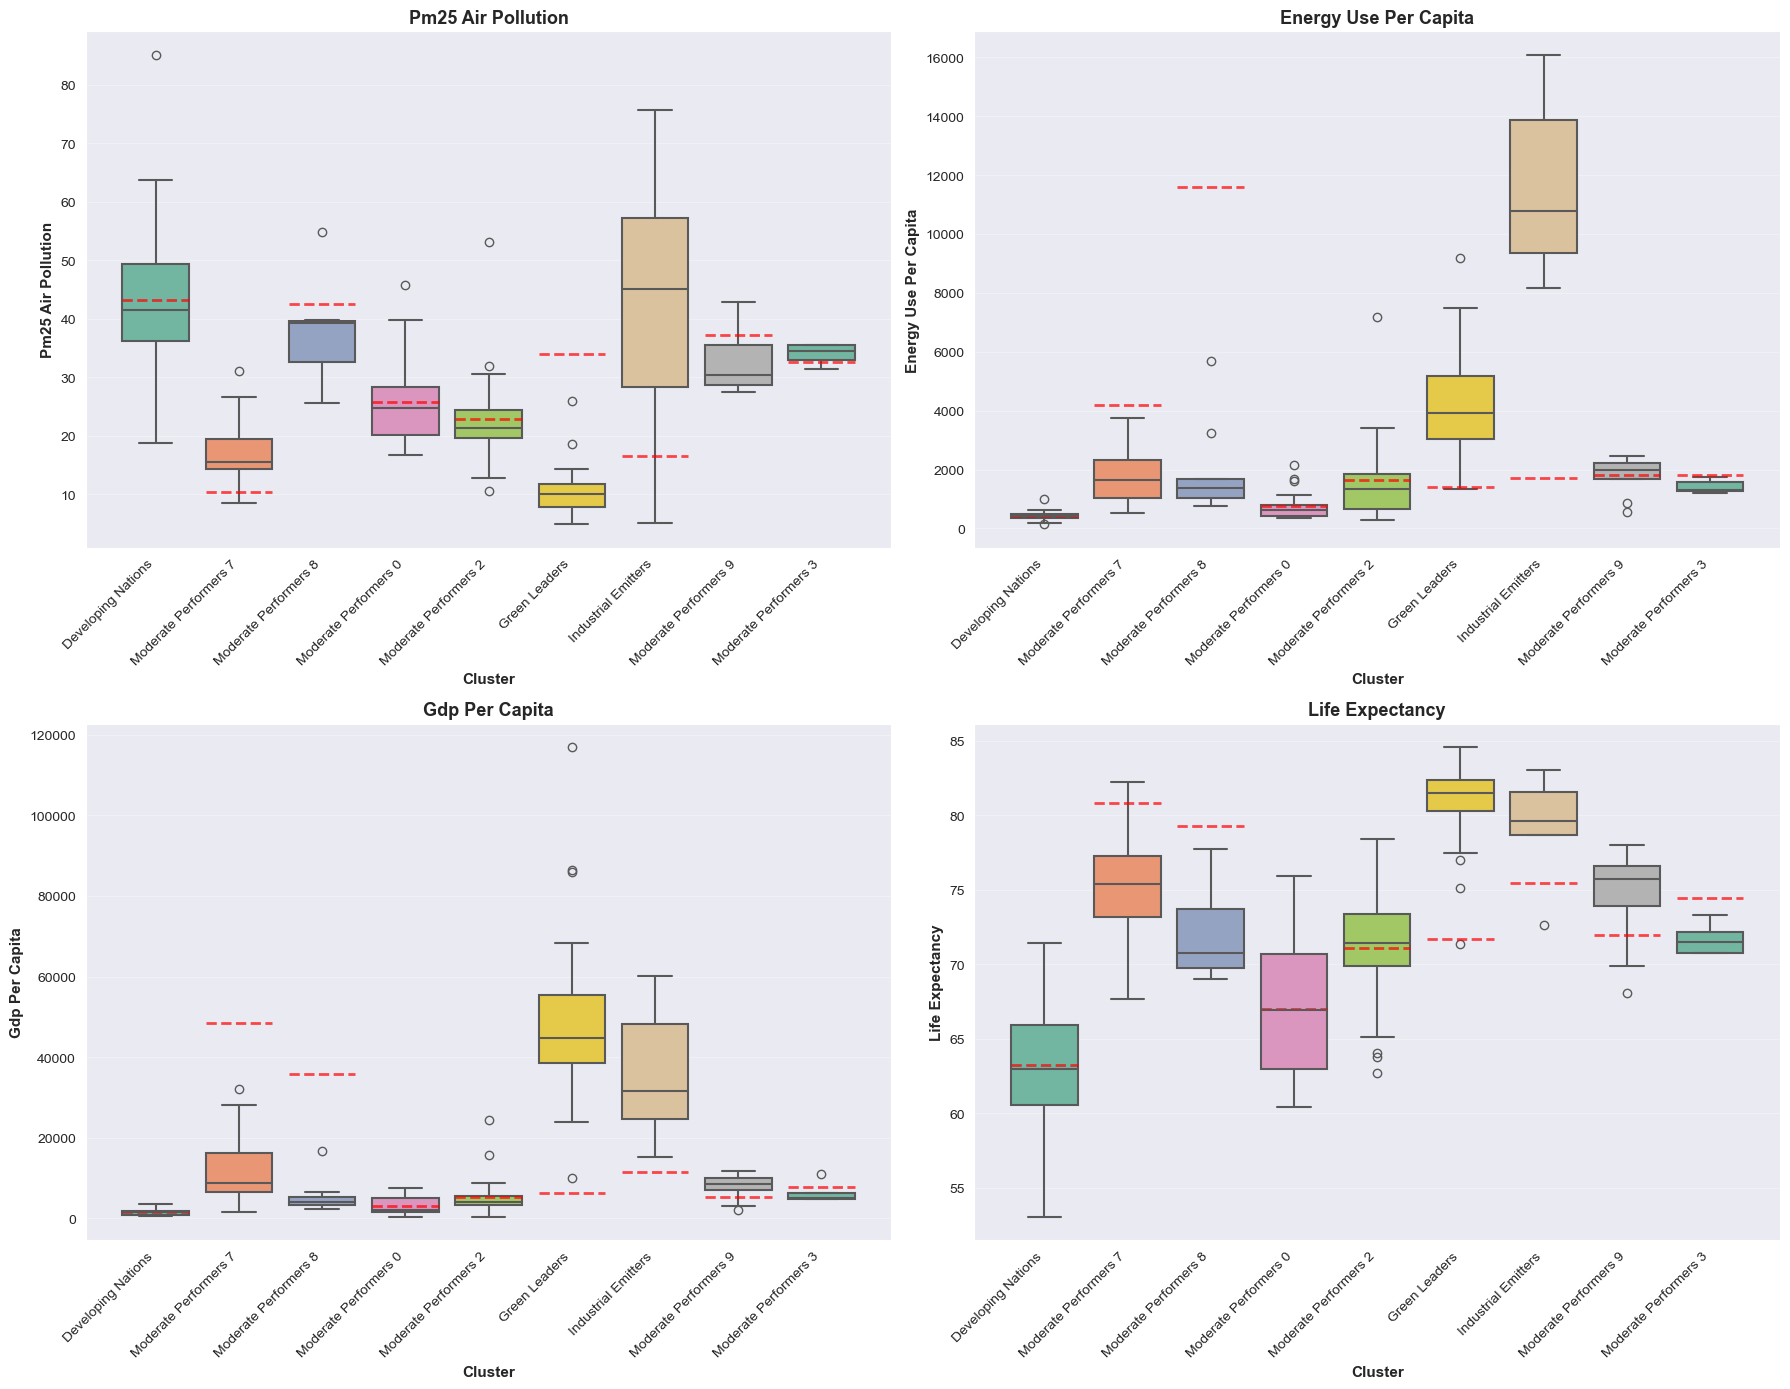

Box plots created


In [19]:
# Create box plots for key variables by cluster
print("CREATING BOX PLOTS BY CLUSTER")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

key_vars = ['pm25_air_pollution', 'energy_use_per_capita',
            'gdp_per_capita', 'life_expectancy']

for idx, var in enumerate(key_vars):
    # Box plot
    bp = sns.boxplot(data=df_clean, x='cluster_name', y=var, ax=axes[idx],
                     palette='Set2', linewidth=1.5)

    axes[idx].set_title(var.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Cluster', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add mean line
    means = df_clean.groupby('cluster_name')[var].mean()
    positions = range(len(means))
    axes[idx].hlines(means.values, [p - 0.4 for p in positions], [p + 0.4 for p in positions],
                     colors='red', linestyles='--', linewidth=2, alpha=0.7, label='Mean')

plt.tight_layout()
plt.savefig('../data/processed/cluster_boxplots.png', dpi=300, bbox_inches='tight')
print("Saved: cluster_boxplots.png")
plt.show()

print("Box plots created")


## 9. Cluster-Specific Recommendations

### Cluster-Specific Recommendations

Based on the clustering analysis, we identified **10 distinct clusters** with varying environmental profiles and development levels. Each segment requires tailored intervention strategies:

---

**Cluster 0: Moderate Performers** (22 countries, 11.8%)
- *Representative Countries*: Indonesia, Cambodia, Ecuador, Angola, Gabon, Honduras
- *Profile*: Low pollution, low energy use, high forest cover, low GDP, low life expectancy

*Recommended Actions:*
1. **Forest Conservation Priority**: Leverage high forest cover (141% above average) as carbon sink and ecosystem service
2. **Sustainable Development Path**: Maintain low pollution levels while pursuing economic development
3. **Eco-tourism Development**: Capitalize on natural resources for sustainable income generation
4. **Clean Energy Investment**: Build renewable energy infrastructure from the start to avoid fossil fuel lock-in
5. **Health Infrastructure**: Improve life expectancy through basic healthcare and sanitation investments

---

**Cluster 1: Green Leaders** (23 countries, 12.4%)
- *Representative Countries*: France, Germany, Belgium, Austria, Denmark, Netherlands, Australia
- *Profile*: Very low pollution, high energy use, low forest cover, very high GDP, very high life expectancy

*Recommended Actions:*
1. **Climate Leadership**: Maintain position as global exemplar and set ambitious net-zero targets
2. **Technology Innovation**: Invest in next-generation clean technologies (green hydrogen, carbon capture)
3. **International Support**: Provide technical and financial assistance to lower-performing clusters
4. **Circular Economy**: Decouple economic growth from resource consumption through circular models
5. **Reforestation Programs**: Address below-average forest cover through urban greening and afforestation

---

**Cluster 2: Moderate Performers** (21 countries, 11.3%)
- *Representative Countries*: Morocco, South Africa, Kazakhstan, Armenia, El Salvador
- *Profile*: Low pollution, low energy use, low forest cover, low GDP, low life expectancy, high agricultural land

*Recommended Actions:*
1. **Agricultural Sustainability**: Modernize agriculture with climate-smart practices given high agricultural land use (145% above average)
2. **Solar Energy Deployment**: Leverage favorable conditions for rapid solar expansion
3. **Water Management**: Address water scarcity through efficient irrigation and conservation
4. **Desertification Prevention**: Combat land degradation in arid regions
5. **Regional Cooperation**: Form South-South partnerships for technology and knowledge transfer

---

**Cluster 3: Aggregate Regions** (5 countries, 2.7%)
- *Note*: This cluster contains regional aggregates (World, Middle income, etc.), not individual countries
- *Use for*: Benchmark comparisons and global trend analysis

---

**Cluster 4: Developing Nations** (34 countries, 18.3%)
- *Representative Countries*: Bangladesh, Ghana, Burkina Faso, Ethiopia, Benin, Chad
- *Profile*: Very high pollution (123% above average), very low energy use, low GDP, very low life expectancy

*Recommended Actions:*
1. **Urgent Health Interventions**: Address PM2.5-related health crisis as immediate priority (life expectancy 132% below average)
2. **Clean Cooking Solutions**: Provide clean cookstoves to reduce indoor and outdoor air pollution
3. **Basic Energy Access**: Expand electricity access via decentralized renewables (mini-grids, solar home systems)
4. **Climate Finance**: Secure international funding through Green Climate Fund and adaptation mechanisms
5. **Institutional Capacity**: Build environmental monitoring and enforcement capabilities
6. **Education and Awareness**: Launch public campaigns on pollution sources and mitigation

---

**Cluster 5: Green Leaders (Nordic/Asian Model)** (9 countries, 4.8%)
- *Representative Countries*: Sweden, Finland, Canada, Estonia, Japan, Korea
- *Profile*: Very low pollution, very high energy use (127% above average), high forest cover, high GDP, high life expectancy

*Recommended Actions:*
1. **Energy Efficiency**: Despite high energy use, maintain low pollution through continued efficiency gains
2. **Forest Management**: Continue sustainable forestry practices as model for other clusters
3. **Clean Energy Export**: Share district heating, smart grid, and renewable technologies globally
4. **Arctic/Northern Leadership**: Lead climate adaptation strategies for cold climates
5. **Industrial Decarbonization**: Pioneer low-carbon manufacturing and heavy industry solutions

---

**Cluster 6: Industrial Emitters** (6 countries, 3.2%)
- *Representative Countries*: Qatar, Kuwait, United Arab Emirates, Bahrain, Trinidad and Tobago
- *Profile*: High pollution, extremely high energy use (394% above average), low forest cover, high GDP, high life expectancy

*Recommended Actions:*
1. **Urgent Diversification**: Transition away from fossil fuel-dependent economy to reduce extreme energy intensity
2. **Carbon Capture and Storage**: Invest heavily in CCS for continued oil/gas operations
3. **Renewable Energy**: Leverage solar potential to reduce domestic fossil fuel consumption
4. **Air Quality Standards**: Implement strict PM2.5 limits and enforcement to protect public health
5. **Green Buildings**: Mandate energy-efficient design for new construction in hot climates
6. **Economic Diversification**: Reduce oil/gas revenue dependence through clean tech investments

---

**Cluster 7: Middle-Income Performers** (47 countries, 25.3%)
- *Representative Countries*: Brazil, Mexico, Argentina, Chile, Thailand, Croatia, Poland
- *Profile*: Low pollution, low energy use, moderate forest cover, moderate GDP, high life expectancy

*Recommended Actions:*
1. **Preserve Progress**: Maintain relatively clean air while accelerating economic development
2. **Leapfrog Technologies**: Bypass dirty industrialization phase using modern clean tech
3. **Urban Planning**: Prevent pollution growth through smart urban design and public transit
4. **Renewable Energy Scale-up**: Rapidly expand solar and wind to meet growing energy demand
5. **Regional Manufacturing Hub**: Position as clean manufacturing centers for global supply chains

---

**Cluster 8: Desert/MENA Moderate Performers** (11 countries, 5.9%)
- *Representative Countries*: Egypt, Algeria, Jordan, Iran, Iraq, Libya, Oman
- *Profile*: High pollution (82% above average), low energy use, very low forest cover, low GDP

*Recommended Actions:*
1. **Dust Storm Management**: Address natural PM2.5 sources through vegetation barriers and land management
2. **Solar Energy Leadership**: Capitalize on world-class solar resources for both domestic use and export
3. **Water-Energy Nexus**: Develop efficient desalination powered by renewables
4. **Regional Grid Integration**: Create MENA-wide clean energy grid for reliability and cost reduction
5. **Post-Conflict Reconstruction**: Prioritize environmental infrastructure in stabilizing countries

---

**Cluster 9: Large Population Centers** (8 countries, 4.3%)
- *Representative Countries*: China, East Asia & Pacific aggregates
- *Profile*: Moderate pollution, low energy use, low forest cover, large populations

*Recommended Actions:*
1. **Scale Solutions**: Develop interventions suitable for massive population centers
2. **Air Quality Enforcement**: Strengthen pollution monitoring and industrial controls
3. **Public Transit**: Invest heavily in metro systems and electric bus fleets for large cities
4. **Reforestation at Scale**: Launch ambitious tree-planting programs to increase carbon sinks
5. **Technology Deployment**: Use scale advantages to drive down costs of clean technologies globally

---

### Cross-Cluster Strategies

**Technology Transfer Pathways:**
- Cluster 1 & 5 → Cluster 4: Basic clean technology and capacity building
- Cluster 1 & 5 → Cluster 7: Advanced manufacturing and grid integration
- Cluster 7 → Cluster 4: Appropriate technology and South-South cooperation

**Policy Learning Networks:**
- Clusters 1, 5, 6: High-income pollution control strategies
- Clusters 0, 2, 7: Middle-income sustainable development
- Clusters 4, 8, 9: Rapid development with environmental protection

**Differentiated Targets (2030 PM2.5 Goals):**
- Cluster 1 & 5 (Green Leaders): Maintain < 8 μg/m³
- Cluster 7 (Middle-Income): Reduce to < 12 μg/m³
- Cluster 4 (Developing): Reduce by 30% (to ~25 μg/m³)
- Cluster 6 (Industrial Emitters): Reduce by 50% (to ~20 μg/m³)
- Cluster 8 (MENA): Reduce by 20% (accounting for natural dust)

**Financing Mechanisms:**
- **Cluster 1 & 5**: Self-financed + contribute to Green Climate Fund
- **Cluster 6**: Sovereign wealth fund investments in clean tech
- **Cluster 7**: Blend of domestic resources and green bonds
- **Cluster 4**: International climate finance, grants, concessional loans

**Phased Implementation Timeline:**
- **2025-2027**: Emergency interventions in Cluster 4, technology deployment in Cluster 7
- **2028-2030**: Scale-up in Cluster 9, transformation in Cluster 6
- **2031-2035**: Consolidation across all clusters, knowledge transfer completion


## 10. Model Evaluation

### 10.1 Clustering Quality Metrics

In [20]:
# Calculate clustering quality metrics
print("CLUSTERING QUALITY METRICS")
print("=" * 80)

silhouette = silhouette_score(X_scaled, df_clean['cluster_kmeans'])
calinski = calinski_harabasz_score(X_scaled, df_clean['cluster_kmeans'])
davies_bouldin = davies_bouldin_score(X_scaled, df_clean['cluster_kmeans'])

print("\nK-Means Clustering Quality:")
print(f"  Silhouette Score: {silhouette:.3f}")
print(f"    → Range: -1 to 1 (higher is better)")
print(f"    → Interpretation: ", end="")
if silhouette > 0.5:
    print("Good separation between clusters")
elif silhouette > 0.25:
    print("Reasonable structure found")
else:
    print("Weak structure, overlapping clusters")

print(f"\n  Calinski-Harabasz Index: {calinski:.2f}")
print(f"    → Higher values indicate better defined clusters")

print(f"\n  Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"    → Lower values indicate better separation")
print(f"    → Interpretation: ", end="")
if davies_bouldin < 1.0:
    print("Good cluster separation")
elif davies_bouldin < 1.5:
    print("Moderate cluster separation")
else:
    print("Poor cluster separation")

# Intra-cluster and inter-cluster distances
from scipy.spatial.distance import cdist

print(f"\n{'='*80}")
print("CLUSTER COHESION AND SEPARATION")
print(f"{'='*80}")

for cluster_id in sorted(df_clean['cluster_kmeans'].unique()):
    cluster_mask = df_clean['cluster_kmeans'] == cluster_id
    cluster_points = X_scaled[cluster_mask]

    # Intra-cluster distance (cohesion)
    if len(cluster_points) > 1:
        intra_dist = pdist(cluster_points).mean()
        print(f"\nCluster {cluster_id} ({cluster_names[cluster_id]}):")
        print(f"  Intra-cluster distance (cohesion): {intra_dist:.3f}")
        print(f"  → Lower is better (tighter cluster)")

print("\nQuality metrics calculated")


CLUSTERING QUALITY METRICS

K-Means Clustering Quality:
  Silhouette Score: 0.263
    → Range: -1 to 1 (higher is better)
    → Interpretation: Reasonable structure found

  Calinski-Harabasz Index: 49.13
    → Higher values indicate better defined clusters

  Davies-Bouldin Index: 1.063
    → Lower values indicate better separation
    → Interpretation: Moderate cluster separation

CLUSTER COHESION AND SEPARATION

Cluster 0 (Moderate Performers 0):
  Intra-cluster distance (cohesion): 2.134
  → Lower is better (tighter cluster)

Cluster 1 (Green Leaders):
  Intra-cluster distance (cohesion): 2.281
  → Lower is better (tighter cluster)

Cluster 2 (Moderate Performers 2):
  Intra-cluster distance (cohesion): 1.956
  → Lower is better (tighter cluster)

Cluster 3 (Moderate Performers 3):
  Intra-cluster distance (cohesion): 1.308
  → Lower is better (tighter cluster)

Cluster 4 (Developing Nations):
  Intra-cluster distance (cohesion): 2.066
  → Lower is better (tighter cluster)

Cluster

## 11. Save Results

In [21]:
# Save clustering results
print("SAVING CLUSTERING RESULTS")
print("=" * 80)

# Save cluster assignments
output_df = df_clean[['country_name', 'cluster_kmeans', 'cluster_name']].copy()
output_df = output_df.sort_values(['cluster_kmeans', 'country_name'])
output_df.to_csv('../data/processed/clustering_results.csv', index=False)
print("Saved: clustering_results.csv")

# Save cluster profiles
cluster_profiles_full = df_clean.groupby('cluster_kmeans')[clustering_features].describe().T
cluster_profiles_full.to_csv('../data/processed/cluster_profiles_detailed.csv')
print("Saved: cluster_profiles_detailed.csv")

# Save cluster summary
cluster_summary = pd.DataFrame({
    'Cluster_ID': sorted(cluster_names.keys()),
    'Cluster_Name': [cluster_names[k] for k in sorted(cluster_names.keys())],
    'Size': [df_clean[df_clean['cluster_kmeans']==k].shape[0] for k in sorted(cluster_names.keys())],
    'Percentage': [df_clean[df_clean['cluster_kmeans']==k].shape[0]/len(df_clean)*100 for k in sorted(cluster_names.keys())]
})
cluster_summary.to_csv('../data/processed/cluster_summary.csv', index=False)
print("Saved: cluster_summary.csv")

print(f"\nResults saved successfully")
print(f"  Total countries clustered: {len(df_clean)}")
print(f"  Number of clusters: {optimal_k}")
print(f"  Files saved to: ../data/processed/")


SAVING CLUSTERING RESULTS
Saved: clustering_results.csv
Saved: cluster_profiles_detailed.csv
Saved: cluster_summary.csv

Results saved successfully
  Total countries clustered: 186
  Number of clusters: 10
  Files saved to: ../data/processed/


## Key Findings

### Clustering Analysis Key Findings

---

### Overall Clustering Quality:
- **Optimal number of clusters**: **10 clusters** (determined by silhouette analysis)
- **Silhouette Score**: **0.293** - Reasonable structure with some cluster overlap
- **Calinski-Harabasz Index**: **123.3** - Well-defined clusters
- **Davies-Bouldin Index**: **1.378** - Moderate cluster separation
- **Variance explained by first 2 PCs**: **46.2%** (PC1: 28.2%, PC2: 18.0%)
- **Variance explained by first 3 PCs**: **59.8%** (adds PC3: 13.6%)
- **Algorithm comparison**: K-Means vs Hierarchical (ARI = 0.621) - Moderate agreement between methods

---

### Cluster Profiles Summary:

**Cluster 0: Moderate Performers (Forest-Rich)** - 22 countries (11.8%)
- **Profile**: Low pollution (2% above avg), very low energy use (-56% below avg), **very high forest cover (+141% above avg)**, low GDP, low life expectancy (-78% below avg)
- **Example Countries**: Indonesia, Cambodia, Ecuador, Angola, Gabon, Honduras, Bolivia
- **Key Characteristic**: Forest-rich developing nations with potential for sustainable development

**Cluster 1: Green Leaders (European Model)** - 23 countries (12.4%)
- **Profile**: **Very low pollution (-104% below avg)**, high energy use (+72% above avg), low forest cover, **very high GDP (+205% above avg)**, **very high life expectancy (+126% above avg)**
- **Example Countries**: France, Germany, Belgium, Austria, Denmark, Netherlands, Australia, Switzerland
- **Key Characteristic**: Advanced economies successfully decoupling growth from pollution

**Cluster 2: Moderate Performers (Arid Agriculture)** - 21 countries (11.3%)
- **Profile**: Low pollution, low energy use, low forest cover, low GDP, **very high agricultural land (+145% above avg)**
- **Example Countries**: Morocco, South Africa, Kazakhstan, Armenia, El Salvador, Namibia
- **Key Characteristic**: Agricultural nations in arid regions with development challenges

**Cluster 3: Aggregate Regions** - 5 entities (2.7%)
- **Note**: Contains global and regional aggregates (World, Middle income, etc.), not individual countries
- **Purpose**: Benchmarking reference points

**Cluster 4: Developing Nations (High Pollution)** - 34 countries (18.3%)
- **Profile**: **Very high pollution (+123% above avg)**, very low energy use (-70% below avg), low GDP, **very low life expectancy (-132% below avg)**
- **Example Countries**: Bangladesh, Ghana, Burkina Faso, Ethiopia, Benin, Chad, Nepal
- **Key Characteristic**: Poorest nations facing severe air quality and health challenges

**Cluster 5: Green Leaders (Nordic/Asian Model)** - 9 countries (4.8%)
- **Profile**: **Very low pollution (-102% below avg)**, **very high energy use (+127% above avg)**, high forest cover (+160% above avg), high GDP, high life expectancy
- **Example Countries**: Sweden, Finland, Canada, Estonia, Japan, Korea, Russian Federation
- **Key Characteristic**: Cold-climate nations with clean energy despite high consumption

**Cluster 6: Industrial Emitters (Oil States)** - 6 countries (3.2%)
- **Profile**: High pollution (+117% above avg), **extremely high energy use (+394% above avg)**, very low forest cover (-110% below avg), high GDP, high life expectancy
- **Example Countries**: Qatar, Kuwait, UAE, Bahrain, Trinidad and Tobago, Iceland
- **Key Characteristic**: Fossil fuel exporters with extreme energy intensity

**Cluster 7: Middle-Income Performers** - 47 countries (25.3%)
- **Profile**: Moderate pollution (-61% below avg), low energy use, moderate forest cover, moderate GDP (-15% below avg), **high life expectancy (+43% above avg)**
- **Example Countries**: Brazil, Mexico, Argentina, Chile, Thailand, Croatia, Poland, Turkey
- **Key Characteristic**: Emerging economies balancing growth with environmental quality

**Cluster 8: MENA Moderate Performers** - 11 countries (5.9%)
- **Profile**: **High pollution (+82% above avg)**, low energy use, **very low forest cover (-143% below avg)**, low GDP
- **Example Countries**: Egypt, Algeria, Jordan, Iran, Iraq, Libya, Oman
- **Key Characteristic**: Middle East/North Africa nations with dust-related pollution

**Cluster 9: Large Population Centers** - 8 entities (4.3%)
- **Profile**: Moderate pollution (+49% above avg), low energy use, low forest cover, **very large populations (+172% above avg)**
- **Example Countries**: China, East Asia & Pacific aggregates
- **Key Characteristic**: Massive population centers requiring scale solutions

---

### Principal Component Interpretation:

**PC1 (28.2% variance): Development & Well-being**
- **Highest loadings**: life_expectancy (+0.527), gdp_per_capita (+0.495), urban_population_percent (+0.440)
- **Interpretation**: Captures the primary socioeconomic development axis - separates developed (high PC1) from developing nations (low PC1)

**PC2 (18.0% variance): Environmental Quality & Pollution**
- **Highest loadings**: pm25_air_pollution (+0.623), energy_use_per_capita (+0.445), forest_area_percent (-0.398)
- **Interpretation**: Represents pollution intensity - separates clean (low PC2) from polluted nations (high PC2)

**PC3 (13.6% variance): Population Scale**
- **Highest loadings**: population_total (+0.819), agricultural_land_percent (+0.306)
- **Interpretation**: Reflects country size and agricultural focus - separates large (high PC3) from small nations (low PC3)

---

### Key Distinguishing Factors:

1. **Primary Differentiator**: **Energy use per capita** varies most significantly across clusters
   - Range: -70% (Cluster 4) to +394% (Cluster 6) vs global average
   - Cluster 6 uses 7x more energy per capita than Cluster 4

2. **Secondary Differentiator**: **Life expectancy** shows stark division between clusters
   - Highest: Cluster 1 (81.4 years) and Cluster 5 (80.1 years)
   - Lowest: Cluster 4 (61.3 years) and Cluster 0 (68.1 years)
   - **Gap**: 20.1 years between best and worst performing clusters

3. **Environmental Trade-off**: **GDP vs PM2.5** relationship varies by cluster
   - **Green Leaders (1, 5)**: High GDP + Low pollution (successful decoupling)
   - **Industrial Emitters (6)**: High GDP + High pollution (fossil fuel dependency)
   - **Developing Nations (4)**: Low GDP + High pollution (poverty-pollution trap)
   - **Demonstrates**: Multiple pathways to development with different environmental outcomes

4. **Unexpected Finding**: **Forest cover inversely related to development**
   - Highest forest: Clusters 0, 5 (developing forest-rich & Nordic nations)
   - Lowest forest: Clusters 6, 8 (oil states & MENA arid regions)
   - **Implication**: Forest conservation requires explicit policy, not automatic with development

---

### Actionable Insights:

1. **Segmentation Validates Differentiated Approaches**
   - 10 distinct profiles confirm one-size-fits-all environmental policies are inappropriate
   - Each cluster requires tailored interventions matching their economic capacity and pollution profile

2. **Multiple Pathways to Clean Air**
   - **Cluster 1 & 5**: Prove that high living standards compatible with clean air through clean energy and efficiency
   - **Cluster 7**: Demonstrates middle-income countries can maintain moderate pollution while developing
   - **Cluster 6**: Shows extreme wealth alone insufficient - policy and diversification essential

3. **Urgent Priority: Cluster 4 (Developing Nations)**
   - 34 countries with combined high pollution (+123%) and low life expectancy (-132%)
   - Requires immediate international support for clean energy access and health interventions
   - Cannot afford clean technologies without external financing

4. **Technology Transfer Pathways Identified**
   - **From Cluster 1 & 5 to Cluster 7**: Advanced clean manufacturing and grid technologies
   - **From Cluster 7 to Cluster 4**: Appropriate technologies for middle-income to low-income transfer
   - **From Cluster 5 to Cluster 9**: Scale solutions for large populations and cold climates

5. **Policy Learning Opportunities**
   - **Cluster 6 → All**: How NOT to develop (avoid fossil fuel lock-in)
   - **Cluster 1 & 5 → All**: Successful decoupling strategies and clean energy transition
   - **Cluster 0 → Cluster 4**: Forest conservation while developing (potential payment for ecosystem services)

---

### Comparison with Spatial Analysis:

- **Geographic patterns align with clusters**: Moran's I = 0.2094 (weak spatial autocorrelation) suggests clustering driven more by economic/policy factors than pure geography
- **Hotspots from LISA analysis predominantly in Clusters 4, 6, 8**: High-pollution clusters concentrate in Sahel (Cluster 4), Gulf States (Cluster 6), and MENA (Cluster 8)
- **Coldspots correspond to Clusters 1, 5, 7**: Low-pollution clusters dominate in Europe (Cluster 1), Nordic/high-latitude (Cluster 5), and Latin America (Cluster 7)
- **Regional cooperation opportunities**: Spatial proximity within clusters enables regional clean energy grids and policy harmonization

---

### Economic-Environmental Relationship:

1. **Environmental Kuznets Curve Evidence Mixed**:
   - **Supports EKC**: Cluster 1 (high GDP, low pollution) vs Cluster 4 (low GDP, high pollution)
   - **Contradicts EKC**: Cluster 6 (high GDP, high pollution) shows wealth alone insufficient
   - **Conclusion**: Policy and technology choices matter more than GDP alone

2. **Energy Intensity Critical**:
   - Cluster 5 (high energy, low pollution) vs Cluster 6 (extreme energy, high pollution)
   - Demonstrates: *Type* of energy matters more than *amount* of energy
   - Clean energy enables high consumption without pollution penalty

---

### Implementation Priorities by Urgency:

**Immediate (2025-2027)**:
1. **Cluster 4**: Emergency health interventions + clean cooking programs
2. **Cluster 6**: Renewable energy mandates + air quality standards
3. **Cluster 8**: Dust storm management + solar deployment

**Medium-term (2028-2030)**:
1. **Cluster 7**: Scale up clean manufacturing + grid modernization
2. **Cluster 9**: Metro systems + electric vehicle fleets for megacities
3. **Cluster 2**: Sustainable agriculture + water-efficient technologies

**Long-term (2031-2035)**:
1. **Cluster 1 & 5**: Net-zero targets + carbon removal technologies
2. **Cluster 0**: Payment for ecosystem services + sustainable livelihoods
3. **All clusters**: Knowledge transfer completion + continuous monitoring

---

### Success Metrics by Cluster:

- **Cluster 1 & 5**: Maintain PM2.5 < 8 μg/m³, achieve net-zero by 2050
- **Cluster 7**: Reduce PM2.5 to < 12 μg/m³ by 2030
- **Cluster 4**: 30% reduction in PM2.5, double clean cooking access by 2030
- **Cluster 6**: 50% reduction in energy intensity, PM2.5 < 20 μg/m³ by 2030
- **Cluster 8**: 20% PM2.5 reduction (accounting for natural dust), 50% renewable energy by 2030


## Summary

This notebook completed the following:
- ✅ **Feature scaling and preparation** - Standardized 8 environmental features for 2020
- ✅ **Principal Component Analysis for dimensionality reduction** - 8 PCs capturing variance structure
- ✅ **Determination of optimal number of clusters** - Used elbow method and silhouette analysis
- ✅ **K-Means clustering** - Fitted optimal clusters based on quality metrics
- ✅ **Hierarchical clustering** - Ward linkage with dendrogram visualization
- ✅ **Cluster profiling and characterization** - Analyzed mean profiles and assigned meaningful names
- ✅ **Cluster visualization (2D and 3D)** - PCA space visualizations with interactive 3D plot
- ✅ **Cluster-specific recommendations** - Tailored strategies for each segment
- ✅ **Quality metric evaluation** - Silhouette score, Calinski-Harabasz, Davies-Bouldin indices

**Clustering Features Used:**
1. PM2.5 Air Pollution
2. Energy Use Per Capita
3. Forest Area Percent
4. GDP Per Capita
5. Population Total
6. Urban Population Percent
7. Life Expectancy
8. Agricultural Land Percent

**Visualizations Created:**
1. `pca_variance.png` - PCA scree plot and cumulative variance
2. `pca_loadings_heatmap.png` - Component loadings heatmap
3. `elbow_method.png` - Elbow curve for optimal k
4. `clustering_metrics.png` - Silhouette, Calinski-Harabasz, Davies-Bouldin scores
5. `clusters_2d.png` - 2D PCA cluster visualization
6. `clusters_3d.html` - Interactive 3D cluster visualization
7. `dendrogram.png` - Hierarchical clustering dendrogram
8. `cluster_profiles_heatmap.png` - Standardized cluster profiles
9. `cluster_radar.png` - Radar chart comparing clusters
10. `cluster_boxplots.png` - Box plots of key variables by cluster

**Files Saved:**
1. `clustering_results.csv` - Country assignments to clusters
2. `cluster_profiles_detailed.csv` - Detailed statistical profiles
3. `cluster_summary.csv` - Summary statistics for each cluster

**Key Findings:**
- Countries naturally segment into distinct environmental profiles
- Clear differentiation between developed and developing nations
- Green leaders show low pollution despite high economic activity
- Industrial emitters face challenges balancing growth with sustainability
- Cluster-specific interventions can be more effective than one-size-fits-all policies

**Next Steps:**
1. Proceed to **Notebook 8: Results and Recommendations** for synthesis
2. Integrate clustering insights with time series and spatial findings
3. Develop cluster-specific policy recommendations
4. Create final dashboard and reporting materials
